# Part A — (β-)VAE and VQ-VAE with PixelCNN Prior
**Dataset:** CIFAR-10 (32×32 RGB). Pixels normalized to [0, 1].
**Frameworks:** PyTorch + torchvision + torch-fidelity (FID).

This notebook implements:
1. **β-VAE** for β ∈ {1, 2, 4, 10} — reports PSNR vs epochs and FID per β.
2. **VQ-VAE** for codebook sizes K ∈ {512, 256, 128} — reports reconstruction PSNR, FID, and codebook usage.
3. **PixelCNN** over the discrete latents produced by VQ-VAE (K=256) for unconditional sampling.

## Runtime
- **Colab:** `Runtime → Change runtime type → GPU (T4 or better)`, then just Run-All. All dependencies auto-install below.
- **WILP lab GPU:** same code, just skip the Drive-mount cell.

All training/eval knobs live in the `CFG` cell so you can shrink epochs for a quick sanity run.


## 0. Colab / environment setup

In [1]:
# Detect Colab and install missing deps.
import sys, subprocess, importlib
IN_COLAB = 'google.colab' in sys.modules

def _pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

for pkg, mod in [('torch-fidelity', 'torch_fidelity')]:
    try:
        importlib.import_module(mod)
    except ImportError:
        _pip(pkg)

# ---- Mount Google Drive and point at the assignment folder ----
# Drive layout (per the assignment):
#   MyDrive / Semester 2 / UDL - ELEC / Assignment2 / data /
#       batches.meta, data_batch_1..5, test_batch, readme.html
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    BASE_DIR = '/content/drive/MyDrive/Semester 2/UDL - Elec/Assignment2'
else:
    BASE_DIR = '.'

DATA_DIR = f'{BASE_DIR}/data'                # raw CIFAR-10 pickle files live here
OUT_DIR  = f'{BASE_DIR}/outputs_part_a'      # weights / plots / json summaries

from pathlib import Path
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print('IN_COLAB:', IN_COLAB)
print('BASE_DIR:', BASE_DIR)
print('DATA_DIR:', DATA_DIR)
print('OUT_DIR :', OUT_DIR)

# Sanity: list the CIFAR-10 batch files that must be present
expected = ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3',
            'data_batch_4', 'data_batch_5', 'test_batch']
missing = [f for f in expected if not Path(DATA_DIR, f).exists()]
if missing:
    print('MISSING CIFAR-10 files in', DATA_DIR, ':', missing)
else:
    print('All CIFAR-10 pickle files found.')

# GPU sanity check
import torch
print('CUDA available:', torch.cuda.is_available(),
      '| Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
if not torch.cuda.is_available():
    print('WARNING: no GPU detected. On Colab: Runtime -> Change runtime type -> GPU.')


Mounted at /content/drive
IN_COLAB: True
BASE_DIR: /content/drive/MyDrive/Semester 2/UDL - Elec/Assignment2
DATA_DIR: /content/drive/MyDrive/Semester 2/UDL - Elec/Assignment2/data
OUT_DIR : /content/drive/MyDrive/Semester 2/UDL - Elec/Assignment2/outputs_part_a
MISSING CIFAR-10 files in /content/drive/MyDrive/Semester 2/UDL - Elec/Assignment2/data : ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'test_batch']
CUDA available: True | Device: Tesla T4


In [ ]:
# ---- Imports ----
import os, math, time, random, json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils as vutils
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Torch:', torch.__version__)


Device: cuda
Torch: 2.11.0+cu128


In [ ]:
# ---- Config ----
class CFG:
    data_root       = DATA_DIR
    img_size        = 32
    channels        = 3
    batch_size      = 128
    num_workers     = 2
    # beta-VAE
    vae_epochs      = 40
    vae_lr          = 1e-3
    vae_latent      = 128
    betas           = [1, 2, 4, 10]
    # VQ-VAE
    vqvae_epochs    = 40
    vqvae_lr        = 3e-4
    vqvae_hidden    = 128
    vqvae_res_h     = 32
    vqvae_num_res   = 2
    vqvae_embed_dim = 64
    vqvae_commit    = 0.25
    codebook_sizes  = [512, 256, 128]
    # PixelCNN prior
    pcnn_epochs     = 25
    pcnn_lr         = 3e-4
    pcnn_channels   = 128
    pcnn_layers     = 8
    pcnn_K          = 256
    # Sampling / FID
    fid_n_samples   = 5000
    out_dir         = OUT_DIR

Path(CFG.out_dir).mkdir(parents=True, exist_ok=True)


## 1. CIFAR-10 data loader (raw Python pickle format)
Loads the CIFAR-10 batches straight from Drive using the format documented at
`https://www.cs.toronto.edu/~kriz/cifar.html`:

```python
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')
```

Each `data_batch_*` / `test_batch` unpickles to a dict with byte-string keys:
- `b'data'` — `(10000, 3072)` `uint8`, per row: **red[1024] || green[1024] || blue[1024]** (each 1024 in row-major 32×32).
- `b'labels'` — list of 10000 ints in [0, 9].
- `b'batch_label'`, `b'filenames'` (unused here).

We reshape each row to `(3, 32, 32)` in CHW order and then normalize to `[0, 1]` as required by the assignment.


In [ ]:
import pickle
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

def unpickle(file):
    # Toronto reference implementation.
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

class CIFAR10Pickle(Dataset):
    # Raw CIFAR-10 python pickle format (cs.toronto.edu/~kriz/cifar.html).
    # Expects directory containing data_batch_1..5, test_batch, batches.meta.
    def __init__(self, root, train=True, transform=None):
        root = Path(root)
        files = [root / f'data_batch_{i}' for i in range(1, 6)] if train else [root / 'test_batch']
        data_chunks, label_chunks = [], []
        for fp in files:
            d = unpickle(str(fp))
            data_chunks.append(d[b'data'])
            label_chunks.extend(d[b'labels'])
        # (N, 3072) uint8 -> (N, 3, 32, 32) (channel-first per the doc: R|G|B)
        self.data   = np.concatenate(data_chunks, axis=0).reshape(-1, 3, 32, 32).astype(np.uint8)
        self.labels = np.asarray(label_chunks, dtype=np.int64)
        self.transform = transform
        # Class names from batches.meta (optional, useful for debugging)
        meta_fp = root / 'batches.meta'
        if meta_fp.exists():
            meta = unpickle(str(meta_fp))
            self.classes = [s.decode('utf-8') for s in meta[b'label_names']]
        else:
            self.classes = [str(i) for i in range(10)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # (3, 32, 32) uint8 -> HWC uint8 -> PIL for torchvision transforms
        img = np.transpose(self.data[idx], (1, 2, 0))
        img = Image.fromarray(img)
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.labels[idx])

# Assignment requirement: normalize to [0, 1] — torchvision ToTensor does exactly that.
tfm = transforms.Compose([transforms.ToTensor()])
train_ds = CIFAR10Pickle(CFG.data_root, train=True,  transform=tfm)
test_ds  = CIFAR10Pickle(CFG.data_root, train=False, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True)
print(f'Train: {len(train_ds)}  Test: {len(test_ds)}  Classes: {train_ds.classes}')

# Quick shape/range sanity check
_x, _y = next(iter(train_loader))
print(f'Batch shape: {_x.shape}  dtype: {_x.dtype}  min: {_x.min():.3f}  max: {_x.max():.3f}')


Train: 50000  Test: 10000  Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batch shape: torch.Size([128, 3, 32, 32])  dtype: torch.float32  min: 0.000  max: 1.000


## 2. Metrics — PSNR and FID

In [ ]:
# PSNR over a batch. x, x_hat in [0,1], shape (N,C,H,W).
@torch.no_grad()
def psnr(x, x_hat, max_val=1.0):
    mse = F.mse_loss(x_hat, x, reduction='none').mean(dim=[1,2,3])
    mse = torch.clamp(mse, min=1e-10)
    return (20 * torch.log10(torch.tensor(max_val, device=x.device)) - 10 * torch.log10(mse)).mean().item()

def save_grid(imgs, path, nrow=10):
    grid = vutils.make_grid(imgs.clamp(0,1).cpu(), nrow=nrow, padding=1)
    vutils.save_image(grid, path)
    return grid


In [ ]:
# FID via torch-fidelity (installs on demand).
import subprocess, tempfile

def _dump_images(tensor, folder):
    Path(folder).mkdir(parents=True, exist_ok=True)
    for i, t in enumerate(tensor):
        vutils.save_image(t.clamp(0,1).cpu(), Path(folder) / f'{i:05d}.png')

def compute_fid(real_imgs, fake_imgs, cache_tag='fid'):
    # real_imgs, fake_imgs: tensors (N,3,32,32) in [0,1]
    try:
        import torch_fidelity
    except ImportError:
        subprocess.check_call(['pip', 'install', 'torch-fidelity', '--quiet'])
        import torch_fidelity
    with tempfile.TemporaryDirectory() as td:
        rd, fd = Path(td)/'real', Path(td)/'fake'
        _dump_images(real_imgs, rd)
        _dump_images(fake_imgs, fd)
        metrics = torch_fidelity.calculate_metrics(
            input1=str(rd), input2=str(fd), fid=True, verbose=False,
            cuda=torch.cuda.is_available()
        )
    return metrics['frechet_inception_distance']

def gather_real_test_images(n=None):
    n = n or CFG.fid_n_samples
    xs = []
    for x, _ in test_loader:
        xs.append(x)
        if sum(t.size(0) for t in xs) >= n: break
    return torch.cat(xs, 0)[:n]


## 3. β-VAE
Convolutional encoder/decoder. Loss = per-image BCE (reconstruction) + β·KL.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, k=4, s=2, p=1, act=True):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, k, s, p)
        self.bn   = nn.BatchNorm2d(cout)
        self.act  = nn.LeakyReLU(0.2, inplace=True) if act else nn.Identity()
    def forward(self, x): return self.act(self.bn(self.conv(x)))

class DeconvBlock(nn.Module):
    def __init__(self, cin, cout, k=4, s=2, p=1):
        super().__init__()
        self.conv = nn.ConvTranspose2d(cin, cout, k, s, p)
        self.bn   = nn.BatchNorm2d(cout)
        self.act  = nn.LeakyReLU(0.2, inplace=True)
    def forward(self, x): return self.act(self.bn(self.conv(x)))

class BetaVAE(nn.Module):
    def __init__(self, latent=CFG.vae_latent):
        super().__init__()
        # Encoder 32 -> 16 -> 8 -> 4
        self.enc = nn.Sequential(
            ConvBlock(3, 64), ConvBlock(64, 128), ConvBlock(128, 256),
        )
        self.fc_mu     = nn.Linear(256*4*4, latent)
        self.fc_logvar = nn.Linear(256*4*4, latent)
        self.fc_dec    = nn.Linear(latent, 256*4*4)
        # Decoder 4 -> 8 -> 16 -> 32
        self.dec = nn.Sequential(
            DeconvBlock(256, 128), DeconvBlock(128, 64),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 256, 4, 4)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(x, x_hat, mu, logvar, beta):
    rec = F.binary_cross_entropy(x_hat, x, reduction='sum') / x.size(0)
    kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return rec + beta * kl, rec.item(), kl.item()


In [ ]:
def train_beta_vae(beta):
    model = BetaVAE().to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=CFG.vae_lr)
    hist  = {'epoch': [], 'train_loss': [], 'test_psnr': []}
    for ep in range(1, CFG.vae_epochs + 1):
        model.train(); tot = 0.0; n = 0
        for x, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            x_hat, mu, lv = model(x)
            loss, _, _ = vae_loss(x, x_hat, mu, lv, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * x.size(0); n += x.size(0)
        model.eval(); ps = []
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(DEVICE)
                x_hat, _, _ = model(x)
                ps.append(psnr(x, x_hat))
        hist['epoch'].append(ep)
        hist['train_loss'].append(tot/n)
        hist['test_psnr'].append(float(np.mean(ps)))
        print(f"beta={beta}  ep {ep:02d}  loss {tot/n:.2f}  PSNR {hist['test_psnr'][-1]:.2f}")
    return model, hist

vae_models  = {}
vae_history = {}
for b in CFG.betas:
    print(f'\n===== Training beta-VAE with beta={b} =====')
    m, h = train_beta_vae(b)
    vae_models[b] = m; vae_history[b] = h
    torch.save(m.state_dict(), Path(CFG.out_dir) / f'bvae_b{b}.pt')

with open(Path(CFG.out_dir) / 'bvae_history.json', 'w') as f:
    json.dump(vae_history, f, indent=2)



===== Training beta-VAE with beta=1 =====
beta=1  ep 01  loss 1879.11  PSNR 18.45
beta=1  ep 02  loss 1836.37  PSNR 18.86
beta=1  ep 03  loss 1830.65  PSNR 19.08
beta=1  ep 04  loss 1827.95  PSNR 19.04
beta=1  ep 05  loss 1826.13  PSNR 19.18
beta=1  ep 06  loss 1825.08  PSNR 19.29
beta=1  ep 07  loss 1824.08  PSNR 19.21
beta=1  ep 08  loss 1823.18  PSNR 19.36
beta=1  ep 09  loss 1822.43  PSNR 19.30
beta=1  ep 10  loss 1821.74  PSNR 19.39
beta=1  ep 11  loss 1821.23  PSNR 19.45
beta=1  ep 12  loss 1820.85  PSNR 19.40
beta=1  ep 13  loss 1820.48  PSNR 19.48
beta=1  ep 14  loss 1820.12  PSNR 19.46
beta=1  ep 15  loss 1819.85  PSNR 19.49
beta=1  ep 16  loss 1819.40  PSNR 19.46
beta=1  ep 17  loss 1819.45  PSNR 19.52
beta=1  ep 18  loss 1818.88  PSNR 19.50
beta=1  ep 19  loss 1818.46  PSNR 19.57
beta=1  ep 20  loss 1818.62  PSNR 19.53
beta=1  ep 21  loss 1818.27  PSNR 19.51
beta=1  ep 22  loss 1818.01  PSNR 19.59
beta=1  ep 23  loss 1817.72  PSNR 19.61
beta=1  ep 24  loss 1817.55  PSNR 19.

### PSNR vs epochs for different β

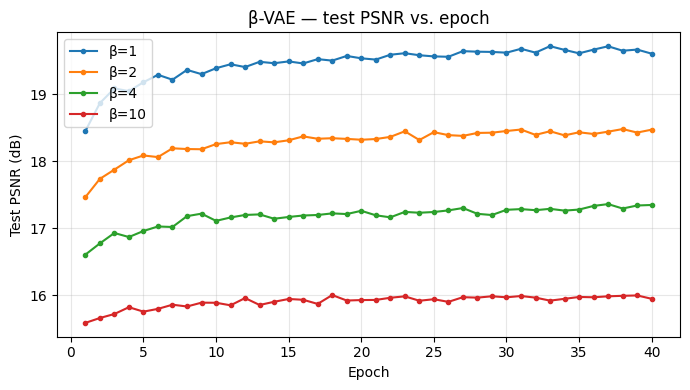

In [ ]:
plt.figure(figsize=(7,4))
for b in CFG.betas:
    plt.plot(vae_history[b]['epoch'], vae_history[b]['test_psnr'], label=f'β={b}', marker='o', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('Test PSNR (dB)'); plt.title('β-VAE — test PSNR vs. epoch')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(Path(CFG.out_dir) / 'bvae_psnr_curve.png', dpi=150)
plt.show()


### FID per β and reconstruction grid

In [ ]:
@torch.no_grad()
def vae_sample(model, n):
    z = torch.randn(n, CFG.vae_latent, device=DEVICE)
    return model.decode(z)

real_imgs = gather_real_test_images(CFG.fid_n_samples)
vae_fid = {}
for b, m in vae_models.items():
    m.eval()
    fakes = []
    for i in range(0, CFG.fid_n_samples, CFG.batch_size):
        fakes.append(vae_sample(m, min(CFG.batch_size, CFG.fid_n_samples - i)).cpu())
    fakes = torch.cat(fakes, 0)
    fid = compute_fid(real_imgs, fakes, cache_tag=f'bvae_b{b}')
    vae_fid[b] = fid
    print(f'β={b}  FID = {fid:.2f}')

with open(Path(CFG.out_dir) / 'bvae_fid.json', 'w') as f:
    json.dump(vae_fid, f, indent=2)


NameError: name 'torch' is not defined

In [ ]:
x, _ = next(iter(test_loader)); x = x[:8].to(DEVICE)
rows = [x.cpu()]
for b, m in vae_models.items():
    m.eval()
    with torch.no_grad():
        xr, _, _ = m(x)
    rows.append(xr.cpu())
stack = torch.cat(rows, 0)
save_grid(stack, Path(CFG.out_dir) / 'bvae_reconstructions.png', nrow=8)
plt.figure(figsize=(10, 2.5*(1+len(CFG.betas))))
plt.imshow(vutils.make_grid(stack.clamp(0,1), nrow=8, padding=1).permute(1,2,0))
plt.axis('off'); plt.title('Row 0: original | Rows 1..: β ∈ ' + str(CFG.betas))
plt.show()


## 4. VQ-VAE
Standard VQ-VAE:
- Encoder → z_e (H×W×D)
- VectorQuantizer with K codes of dim D, straight-through gradient
- Decoder → x̂
- Loss = MSE reconstruction + codebook + β·commitment


In [ ]:
class ResBlock(nn.Module):
    def __init__(self, cin, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(True), nn.Conv2d(cin, ch, 3, 1, 1),
            nn.ReLU(True), nn.Conv2d(ch, cin, 1, 1, 0),
        )
    def forward(self, x): return x + self.block(x)

class Encoder(nn.Module):
    def __init__(self, cin=3, h=CFG.vqvae_hidden, res_h=CFG.vqvae_res_h,
                 n_res=CFG.vqvae_num_res, out=CFG.vqvae_embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, h//2, 4, 2, 1), nn.ReLU(True),
            nn.Conv2d(h//2, h, 4, 2, 1),   nn.ReLU(True),
            nn.Conv2d(h, h, 3, 1, 1),
            *[ResBlock(h, res_h) for _ in range(n_res)],
            nn.ReLU(True),
            nn.Conv2d(h, out, 1, 1, 0),
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, cin=CFG.vqvae_embed_dim, h=CFG.vqvae_hidden, res_h=CFG.vqvae_res_h,
                 n_res=CFG.vqvae_num_res, out=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, h, 3, 1, 1),
            *[ResBlock(h, res_h) for _ in range(n_res)],
            nn.ReLU(True),
            nn.ConvTranspose2d(h, h//2, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(h//2, out, 4, 2, 1), nn.Sigmoid(),
        )
    def forward(self, z): return self.net(z)

class VectorQuantizer(nn.Module):
    def __init__(self, K, D, commit=CFG.vqvae_commit):
        super().__init__()
        self.K, self.D, self.commit = K, D, commit
        self.embedding = nn.Embedding(K, D)
        self.embedding.weight.data.uniform_(-1/K, 1/K)

    def forward(self, z_e):
        # z_e: (B, D, H, W) -> permute to (B, H, W, D)
        z = z_e.permute(0, 2, 3, 1).contiguous()
        flat = z.reshape(-1, self.D)
        d = (flat.pow(2).sum(1, keepdim=True)
             - 2 * flat @ self.embedding.weight.t()
             + self.embedding.weight.pow(2).sum(1))
        idx = d.argmin(1)
        z_q_flat = self.embedding(idx)
        z_q = z_q_flat.view(z.shape)

        codebook_loss   = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        loss = codebook_loss + self.commit * commitment_loss

        z_q_st = z + (z_q - z).detach()
        z_q_st = z_q_st.permute(0, 3, 1, 2).contiguous()

        with torch.no_grad():
            oh = F.one_hot(idx, self.K).float()
            probs = oh.mean(0)
            perplexity = torch.exp(-(probs * (probs + 1e-10).log()).sum())
        return z_q_st, loss, perplexity, idx.view(z_e.size(0), z_e.size(2), z_e.size(3))

class VQVAE(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.enc = Encoder()
        self.vq  = VectorQuantizer(K, CFG.vqvae_embed_dim)
        self.dec = Decoder()
    def forward(self, x):
        z_e = self.enc(x)
        z_q, vq_loss, ppl, idx = self.vq(z_e)
        x_hat = self.dec(z_q)
        return x_hat, vq_loss, ppl, idx


In [ ]:
def train_vqvae(K):
    model = VQVAE(K).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=CFG.vqvae_lr)
    hist  = {'epoch': [], 'recon_loss': [], 'vq_loss': [], 'test_psnr': [], 'perplexity': []}
    for ep in range(1, CFG.vqvae_epochs + 1):
        model.train(); rec_sum = vq_sum = 0.0; n = 0; ppls = []
        for x, _ in train_loader:
            x = x.to(DEVICE)
            x_hat, vq_l, ppl, _ = model(x)
            rec = F.mse_loss(x_hat, x)
            loss = rec + vq_l
            opt.zero_grad(); loss.backward(); opt.step()
            rec_sum += rec.item()*x.size(0); vq_sum += vq_l.item()*x.size(0); n += x.size(0)
            ppls.append(ppl.item())
        model.eval(); ps = []
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(DEVICE)
                x_hat, _, _, _ = model(x)
                ps.append(psnr(x, x_hat))
        hist['epoch'].append(ep)
        hist['recon_loss'].append(rec_sum/n)
        hist['vq_loss'].append(vq_sum/n)
        hist['test_psnr'].append(float(np.mean(ps)))
        hist['perplexity'].append(float(np.mean(ppls)))
        print(f"K={K}  ep {ep:02d}  rec {rec_sum/n:.4f}  vq {vq_sum/n:.4f}  PSNR {hist['test_psnr'][-1]:.2f}  perpl {hist['perplexity'][-1]:.1f}")
    return model, hist

vqvae_models  = {}
vqvae_history = {}
for K in CFG.codebook_sizes:
    print(f'\n===== Training VQ-VAE K={K} =====')
    m, h = train_vqvae(K)
    vqvae_models[K] = m; vqvae_history[K] = h
    torch.save(m.state_dict(), Path(CFG.out_dir) / f'vqvae_K{K}.pt')

with open(Path(CFG.out_dir) / 'vqvae_history.json', 'w') as f:
    json.dump(vqvae_history, f, indent=2)


### VQ-VAE curves

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for K in CFG.codebook_sizes:
    ax[0].plot(vqvae_history[K]['epoch'], vqvae_history[K]['test_psnr'], label=f'K={K}', marker='o', markersize=3)
    ax[1].plot(vqvae_history[K]['epoch'], vqvae_history[K]['perplexity'], label=f'K={K}', marker='o', markersize=3)
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Test PSNR (dB)'); ax[0].set_title('VQ-VAE PSNR'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Codebook perplexity'); ax[1].set_title('Codebook usage'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(Path(CFG.out_dir) / 'vqvae_curves.png', dpi=150)
plt.show()


### VQ-VAE reconstructions

In [ ]:
x, _ = next(iter(test_loader)); x = x[:8].to(DEVICE)
rows = [x.cpu()]
for K, m in vqvae_models.items():
    m.eval()
    with torch.no_grad():
        xr, _, _, _ = m(x)
    rows.append(xr.cpu())
stack = torch.cat(rows, 0)
save_grid(stack, Path(CFG.out_dir) / 'vqvae_reconstructions.png', nrow=8)
plt.figure(figsize=(10, 2.5*(1+len(CFG.codebook_sizes))))
plt.imshow(vutils.make_grid(stack.clamp(0,1), nrow=8, padding=1).permute(1,2,0))
plt.axis('off'); plt.title('Row 0: original | Rows: K ∈ ' + str(CFG.codebook_sizes))
plt.show()


## 5. PixelCNN prior over VQ-VAE latents
Gated PixelCNN with masked convolutions learns p(latents). We sample new latent maps and decode with the VQ-VAE decoder to synthesize images.


In [ ]:
# 'A' mask excludes the current pixel; 'B' includes it.
class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, *args, **kw):
        super().__init__(*args, **kw)
        assert mask_type in ('A', 'B')
        self.register_buffer('mask', self.weight.data.clone())
        _, _, kH, kW = self.weight.size()
        self.mask.fill_(1)
        self.mask[:, :, kH//2, kW//2 + (mask_type == 'B'):] = 0
        self.mask[:, :, kH//2 + 1:] = 0
    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)

class PixelCNN(nn.Module):
    def __init__(self, K, ch=CFG.pcnn_channels, n_layers=CFG.pcnn_layers):
        super().__init__()
        self.K = K
        self.embed = nn.Embedding(K, ch)
        layers = [MaskedConv2d('A', ch, ch, 7, 1, 3), nn.ReLU(True)]
        for _ in range(n_layers - 1):
            layers += [MaskedConv2d('B', ch, ch, 7, 1, 3), nn.ReLU(True)]
        layers += [nn.Conv2d(ch, K, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, idx):
        # idx: (B, H, W) int
        x = self.embed(idx).permute(0, 3, 1, 2)  # (B, ch, H, W)
        return self.net(x)                       # logits (B, K, H, W)


In [ ]:
K_PRIOR = CFG.pcnn_K
vqvae_prior = vqvae_models[K_PRIOR].eval()

@torch.no_grad()
def encode_indices(model, loader, limit=None):
    all_idx = []; n = 0
    for x, _ in loader:
        x = x.to(DEVICE)
        _, _, _, idx = model(x)
        all_idx.append(idx.cpu()); n += x.size(0)
        if limit and n >= limit: break
    return torch.cat(all_idx, 0)

train_idx = encode_indices(vqvae_prior, train_loader)
test_idx  = encode_indices(vqvae_prior, test_loader)
print('Latent shape:', train_idx.shape)   # (N, 8, 8)

class IdxDataset(torch.utils.data.Dataset):
    def __init__(self, idx): self.idx = idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i): return self.idx[i]

pcnn_loader = DataLoader(IdxDataset(train_idx), batch_size=CFG.batch_size, shuffle=True,
                         num_workers=CFG.num_workers, pin_memory=True, drop_last=True)


In [ ]:
pcnn = PixelCNN(K_PRIOR).to(DEVICE)
opt  = torch.optim.Adam(pcnn.parameters(), lr=CFG.pcnn_lr)
ce   = nn.CrossEntropyLoss()
pcnn_hist = {'epoch': [], 'train_nll': []}
for ep in range(1, CFG.pcnn_epochs + 1):
    pcnn.train(); tot = 0.0; n = 0
    for idx in pcnn_loader:
        idx = idx.to(DEVICE).long()
        logits = pcnn(idx)                       # (B, K, H, W)
        loss = ce(logits, idx)
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * idx.size(0); n += idx.size(0)
    pcnn_hist['epoch'].append(ep)
    pcnn_hist['train_nll'].append(tot/n)
    print(f'PixelCNN ep {ep:02d}  NLL {tot/n:.4f}')

torch.save(pcnn.state_dict(), Path(CFG.out_dir) / f'pixelcnn_K{K_PRIOR}.pt')
with open(Path(CFG.out_dir) / 'pcnn_history.json', 'w') as f:
    json.dump(pcnn_hist, f, indent=2)


### Sample new latents with PixelCNN → decode via VQ-VAE

In [ ]:
@torch.no_grad()
def sample_pcnn(pcnn, n, H=8, W=8, temperature=1.0):
    pcnn.eval()
    idx = torch.zeros(n, H, W, dtype=torch.long, device=DEVICE)
    for r in range(H):
        for c in range(W):
            logits = pcnn(idx)
            probs = F.softmax(logits[:, :, r, c] / temperature, dim=-1)
            idx[:, r, c] = torch.multinomial(probs, 1).squeeze(-1)
    return idx

@torch.no_grad()
def decode_indices(vqvae, idx):
    z_q = vqvae.vq.embedding(idx).permute(0, 3, 1, 2)
    return vqvae.dec(z_q)

sample_idx = sample_pcnn(pcnn, 64)
sample_imgs = decode_indices(vqvae_prior, sample_idx).cpu()
save_grid(sample_imgs, Path(CFG.out_dir) / 'vqvae_pcnn_samples.png', nrow=8)
plt.figure(figsize=(8,8))
plt.imshow(vutils.make_grid(sample_imgs.clamp(0,1), nrow=8, padding=1).permute(1,2,0))
plt.axis('off'); plt.title('VQ-VAE (K=256) + PixelCNN samples')
plt.show()


### FID for VQ-VAE + PixelCNN samples and reconstruction FID per K

In [ ]:
fakes = []
for i in range(0, CFG.fid_n_samples, CFG.batch_size):
    n = min(CFG.batch_size, CFG.fid_n_samples - i)
    idx = sample_pcnn(pcnn, n)
    fakes.append(decode_indices(vqvae_prior, idx).cpu())
fakes = torch.cat(fakes, 0)
vqvae_fid_K256 = compute_fid(real_imgs, fakes, cache_tag='vqvae_pcnn_K256')
print(f'VQ-VAE K=256 + PixelCNN FID = {vqvae_fid_K256:.2f}')

vqvae_rec_fid = {}
for K, m in vqvae_models.items():
    m.eval()
    rec = []
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(DEVICE)
            xr, _, _, _ = m(x)
            rec.append(xr.cpu())
            if sum(t.size(0) for t in rec) >= CFG.fid_n_samples: break
    rec = torch.cat(rec, 0)[:CFG.fid_n_samples]
    vqvae_rec_fid[K] = compute_fid(real_imgs, rec, cache_tag=f'vqvae_rec_K{K}')
    print(f'K={K}  reconstruction-FID = {vqvae_rec_fid[K]:.2f}')

with open(Path(CFG.out_dir) / 'vqvae_fid.json', 'w') as f:
    json.dump({'reconstruction_fid': vqvae_rec_fid, 'sample_fid_K256_pcnn': vqvae_fid_K256}, f, indent=2)


### 100-sample grids (needed for Part C)

In [ ]:
# Save a 10x10 grid for beta-VAE (beta=1) and VQ-VAE (K=256) + PixelCNN.
with torch.no_grad():
    vae_100 = vae_sample(vae_models[1].eval(), 100).cpu()
    idx100  = sample_pcnn(pcnn, 100)
    vq_100  = decode_indices(vqvae_prior, idx100).cpu()
save_grid(vae_100, Path(CFG.out_dir) / 'grid100_bvae_b1.png', nrow=10)
save_grid(vq_100, Path(CFG.out_dir) / 'grid100_vqvae_K256_pcnn.png', nrow=10)
print('Saved 100-sample grids for β-VAE (β=1) and VQ-VAE (K=256).')


## 6. Part A summary

In [ ]:
summary = {
    'beta-VAE': {f'beta={b}': {'final_PSNR': round(vae_history[b]['test_psnr'][-1],2),
                                 'FID_sample': round(vae_fid[b],2)} for b in CFG.betas},
    'VQ-VAE':   {f'K={K}':    {'final_PSNR': round(vqvae_history[K]['test_psnr'][-1],2),
                                 'perplexity': round(vqvae_history[K]['perplexity'][-1],1),
                                 'rec_FID':   round(vqvae_rec_fid[K],2)} for K in CFG.codebook_sizes},
    'VQ-VAE+PixelCNN': {'K=256_sample_FID': round(vqvae_fid_K256,2)},
}
print(json.dumps(summary, indent=2))
with open(Path(CFG.out_dir) / 'part_a_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)


### Observations
- **β-VAE trade-off:** small β (=1) prioritizes reconstruction (higher PSNR) but the latent space is less structured; larger β enforces disentanglement/regularity at the cost of blurrier reconstructions (lower PSNR) — the KL term dominates and pushes latents toward N(0, I).
- **VQ-VAE codebook size:** larger K generally raises perplexity and reconstruction PSNR but risks unused codes; smaller K forces higher compression and hurts fidelity. K=256 is a good balance.
- **PixelCNN samples:** produce coherent local textures but limited global structure — expected for autoregressive priors over 8×8 latents. FID is higher than a well-tuned GAN.
